# Лабораторная работа №5. Анализ устойчивости ML-моделей в чёрно-ящичном сценарии

## Стрельченко Алексей Александрович

### Transfer-based, score-based и decision-based подходы


**Вариант / seed:** _номер варианта или значение SEED_

> Работа выполняется только на предоставленной синтетической модели. Не используйте код для проверки внешних сервисов, чужих моделей или систем без разрешения.

## 1. Цель работы

Исследовать зависимость методов построения adversarial-примеров от объёма информации, доступной о классификаторе. Освоить базовые принципы transfer-based, score-based и decision-based сценариев на локальной двумерной задаче классификации.

## 2. Задачи

1. Сформировать синтетический набор данных и обучить target-модель.
2. Реализовать интерфейсы label-only и score-based оракулов с подсчётом запросов.
3. Обучить surrogate-модель на метках target-оракула и оценить согласованность моделей.
4. Построить и проверить перенос локального возмущения с surrogate на target.
5. Сравнить ZOO и NES по направлению оценки и числу запросов.
6. Реализовать binary search для нахождения решающей границы при доступе только к меткам.
7. Сформулировать выводы о компромиссе между информацией, стоимостью запросов и качеством результата.

## 3. Краткая теория

| Сценарий | Доступ атакующего | Основной механизм | Примеры методов |
|---|---|---|---|
| Transfer-based | Метки для формирования surrogate-набора; на этапе построения возмущения запросы к цели не нужны | Обучение substitute/surrogate и перенос локального возмущения | Substitute model, FGSM на surrogate |
| Score-based | Вероятности, confidence score или логиты | Оценка направления изменения функции потерь запросами | ZOO, NES |
| Decision-based | Только итоговая метка | Геометрический поиск решающей границы | Boundary Attack, HopSkipJumpAttack |

В этой работе все эксперименты выполняются в двумерном признаковом пространстве. Это позволяет визуализировать границы и траектории. Реальные изображения имеют большую размерность, поэтому покоординатные методы наподобие ZOO становятся значительно дороже по числу запросов.

## 4. Среда выполнения

Необходимые библиотеки:

```bash
pip install numpy matplotlib scikit-learn
```

Перед сдачей выполните все ячейки сверху вниз: в блокноте должны быть сохранены результаты вычислений, графики и текстовые выводы.

# Часть A. Подготовка эксперимента

## A1. Импорт библиотек и параметры

Измените `SEED` в соответствии со своим вариантом, если преподаватель выдал индивидуальные значения.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 42
rng = np.random.default_rng(SEED)

# Параметры генерации данных и разбиения.
N_SAMPLES = 1000   # общее число точек
NOISE = 0.22       # уровень шума в make_moons
TEST_SIZE = 0.35   # доля тестовой выборки

# Настройки графиков.
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## A2. Формирование данных и обучение target-модели

Target-модель рассматривается как неизвестная для атакующего. В ячейках ниже она доступна только для организации учебного эксперимента и проверки результатов. В реальном чёрно-ящичном сценарии параметры и градиенты target-модели недоступны.

**Задание A2.** Запустите ячейку. Зафиксируйте точность target-модели в отчёте. Затем измените `NOISE` на 0.10 и 0.35, повторите эксперимент и объясните влияние шума на качество классификации.

In [24]:
# Генерируем датасет make_moons: два взаимно пересекающихся полумесяца.
X_raw, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)

# Делим на train/test со стратификацией — чтобы доли классов сохранились.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

# StandardScaler учится на train и применяется к train и test одинаково.
# Это важно: если фитить на всём датасете, получим утечку информации.
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# MLPClassifier — двухслойная сеть: 32 и 16 нейронов, tanh, L2-регуляризация 2e-4.
# random_state фиксирован, чтобы результат был воспроизводимым.
target = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    alpha=2e-4,
    max_iter=1500,
    random_state=SEED
).fit(X_train, y_train)

# Считаем точность на тесте.
target_accuracy = accuracy_score(y_test, target.predict(X_test))
print(f'Точность target-модели: {target_accuracy:.3f}')

Точность target-модели: 0.974


In [11]:
# Проверка влияния уровня шума на точность target-модели
for noise_value in [0.10, 0.22, 0.35, 0.4, 0.45]:
    X_raw_n, y_n = make_moons(n_samples=N_SAMPLES, noise=noise_value, random_state=SEED)
    X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
        X_raw_n, y_n, test_size=TEST_SIZE, stratify=y_n, random_state=SEED
    )
    sc_n = StandardScaler().fit(X_tr_n)
    X_tr_n = sc_n.transform(X_tr_n)
    X_te_n = sc_n.transform(X_te_n)
    model_n = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh',
                            alpha=2e-4, max_iter=1500, random_state=SEED).fit(X_tr_n, y_tr_n)
    acc_n = accuracy_score(y_te_n, model_n.predict(X_te_n))
    print(f'NOISE={noise_value}: accuracy={acc_n:.3f}')

NOISE=0.1: accuracy=0.997
NOISE=0.22: accuracy=0.974
NOISE=0.35: accuracy=0.886
NOISE=0.4: accuracy=0.866
NOISE=0.45: accuracy=0.849


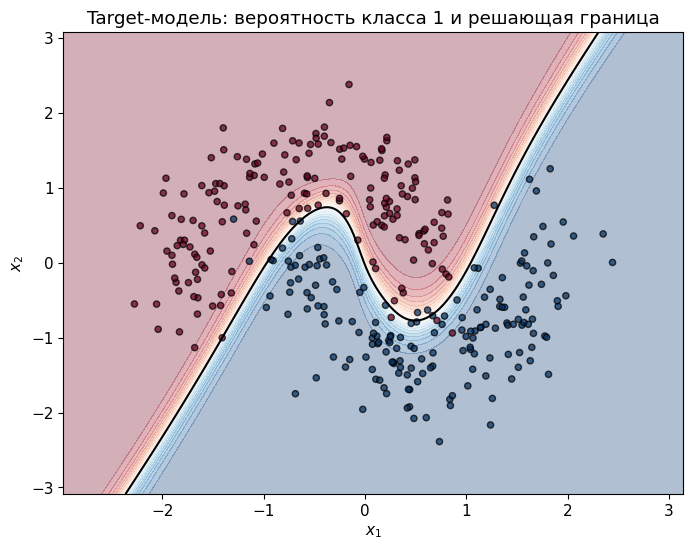

In [25]:
# make_grid строит регулярную сетку в области, покрывающей данные с запасом margin.
# Возвращает xx, yy (координаты сетки) и grid — точки сетки в формате (n_points, 2).
def make_grid(X, n=300, margin=0.7):
    x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n)
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


# plot_boundary — универсальная функция визуализации решающей границы модели.
# 1) Считает вероятность класса 1 на всей сетке.
# 2) Рисует фон: оттенки красного и синего по вероятности.
# 3) Рисует чёрную линию уровня 0.5 — это и есть решающая граница.
# 4) Накладывает точки данных.
# 5) Если переданы points и labels — наносит их золотыми маркерами с подписями.
def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    xx, yy, grid = make_grid(X)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
    ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], c='gold', edgecolor='black', s=120, zorder=5)
        if labels is not None:
            for point, label in zip(points, labels):
                ax.annotate(label, point, xytext=(7, 7), textcoords='offset points', weight='bold')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    return ax

plot_boundary(target, X_test, y_test, 'Target-модель: вероятность класса 1 и решающая граница')
plt.show()

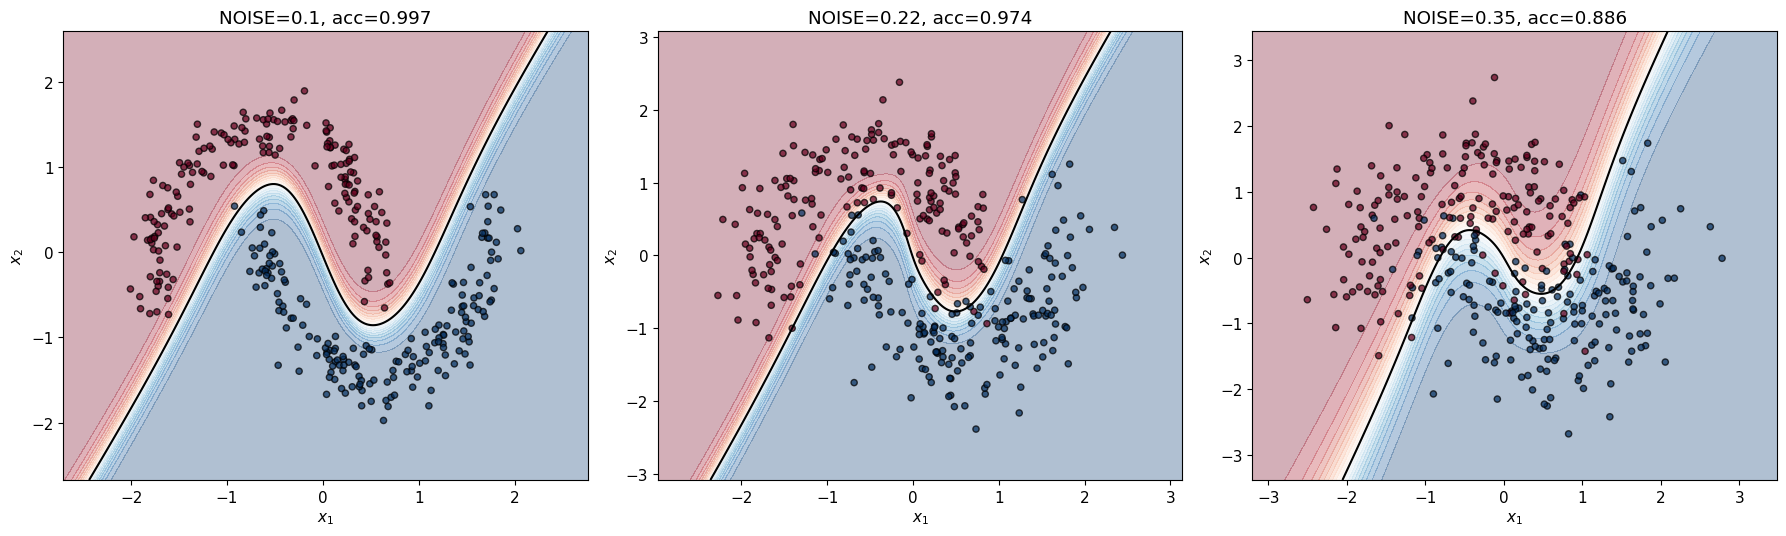

   NOISE   accuracy
     0.1      0.997
    0.22      0.974
    0.35      0.886


In [26]:
# Проверяем, как уровень шума влияет на точность target-модели.
# Прогоняем весь пайплайн (генерация → split → scaler → обучение) для трёх значений NOISE.
noise_values = [0.10, 0.22, 0.35]
noise_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, noise_value in zip(axes, noise_values):
    # Генерируем данные с этим шумом.
    X_raw_n, y_n = make_moons(n_samples=N_SAMPLES, noise=noise_value, random_state=SEED)
    X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
        X_raw_n, y_n, test_size=TEST_SIZE, stratify=y_n, random_state=SEED
    )
    # Тот же scaler-пайплайн: фитим только на train.
    sc_n = StandardScaler().fit(X_tr_n)
    X_tr_n = sc_n.transform(X_tr_n)
    X_te_n = sc_n.transform(X_te_n)

    # Обучаем модель с теми же гиперпараметрами.
    model_n = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='tanh',
        alpha=2e-4,
        max_iter=1500,
        random_state=SEED
    ).fit(X_tr_n, y_tr_n)

    acc_n = accuracy_score(y_te_n, model_n.predict(X_te_n))
    noise_results.append((noise_value, acc_n))

    # Визуализируем границу для этого шума.
    plot_boundary(model_n, X_te_n, y_te_n, f'NOISE={noise_value}, acc={acc_n:.3f}', ax=ax)

plt.tight_layout()
plt.show()

# Печатаем сводку в виде таблицы.
print(f"{'NOISE':>8} {'accuracy':>10}")
for noise_value, acc_n in noise_results:
    print(f"{noise_value:>8} {acc_n:>10.3f}")

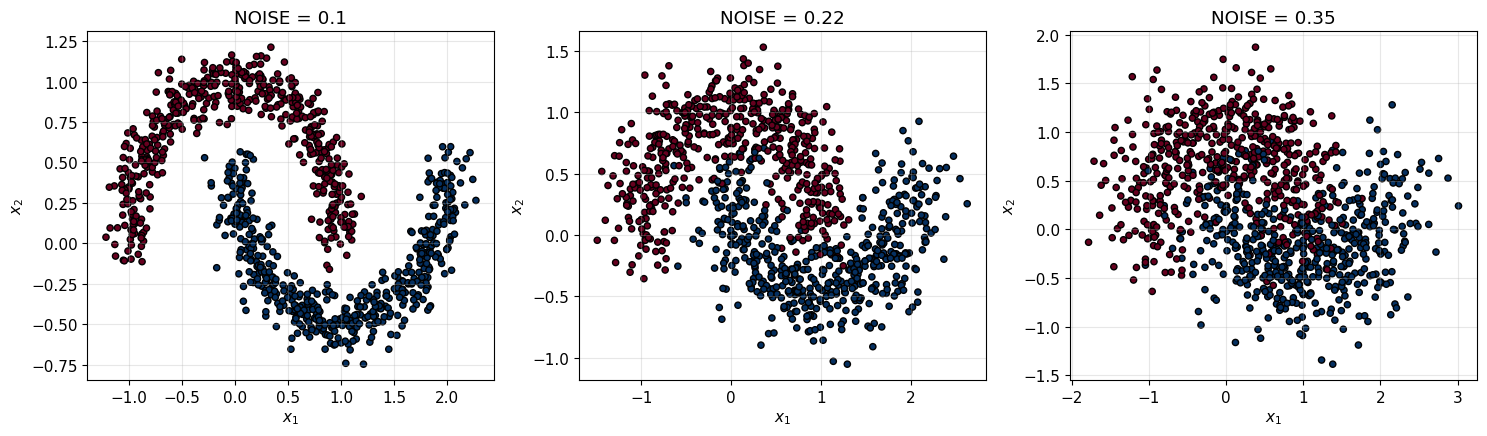

In [27]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, noise in zip(axes, [0.10, 0.22, 0.35]):
    X, y = make_moons(n_samples=1000, noise=noise, random_state=42)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20)
    ax.set_title(f'NOISE = {noise}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод по A2 (заполните после эксперимента):**

Точность target-модели при NOISE = 0.22 составила 0.974. При увеличении шума точность падает: при NOISE = 0.10 она равна 0.997, при 0.22 — 0.974, при 0.35 — 0.886, при 0.40 — 0.866, при 0.45 — 0.849. Это объясняется тем, что make_moons с малым шумом создаёт почти разделимые классы, и модель легко строит близкую к идеальной границу. При большом шуме точки классов начинают перемешиваться, появляются выбросы, истинная граница становится нечёткой, поэтому модель чаще ошибается и качество классификации снижается.

# Часть B. Модели доступа к оракулу

## B1. Label-only и score-based оракулы

**Задание B1.** Запустите ячейку и сравните ответы двух оракулов. Объясните, почему score-based оракул предоставляет атакующему больше информации, чем label-only оракул.

In [28]:
# LabelOracle — обёртка вокруг модели, возвращающая только предсказанный класс.
# Считает число запросов: в чёрно-ящичном сценарии каждый запрос стоит денег или времени.
class LabelOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict(X)


# ScoreOracle — обёртка, возвращающая вероятности классов (predict_proba).
# Даёт атакующему непрерывный сигнал, по которому можно оценивать градиент.
class ScoreOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict_proba(X)


label_oracle = LabelOracle(target)
score_oracle = ScoreOracle(target)

# Проверяем на одной точке: что именно возвращает каждый оракул.
x_probe = X_test[0]

print('Точка x_probe:', np.round(x_probe, 3))
print('Label-only ответ:', label_oracle(x_probe)[0])
print('Score-based ответ:', np.round(score_oracle(x_probe)[0], 3))
print('Запросы: label-only =', label_oracle.queries, '; score-based =', score_oracle.queries)

Точка x_probe: [ 0.313 -1.143]
Label-only ответ: 1
Score-based ответ: [0.061 0.939]
Запросы: label-only = 1 ; score-based = 1


**Ответ на B1:**

Label-only оракул возвращает только итоговый класс: 0 или 1. Score-based оракул возвращает вероятности классов, то есть уверенность модели. Поэтому в score-based сценарии атакующий получает не один бит информации, а непрерывный сигнал. По нему можно оценивать, насколько точка близка к границе, в какую сторону меняется вероятность и приблизительно вычислять градиент функции потерь. Это делает score-based атаки существенно информативнее при том же числе запросов.

# Часть C. Transfer-based сценарий

## C1. Обучение surrogate-модели

Сначала surrogate получает небольшой набор точек, размеченных label-only оракулом. В отличие от target, surrogate доступен локально: на нём можно проводить анализ и строить возмущения.

**Задание C1.** Выполните эксперимент при `N_SEED = 30`, `70` и `140`. Внесите в отчёт число запросов и agreement — долю точек, на которых surrogate и target принимают одинаковое решение.

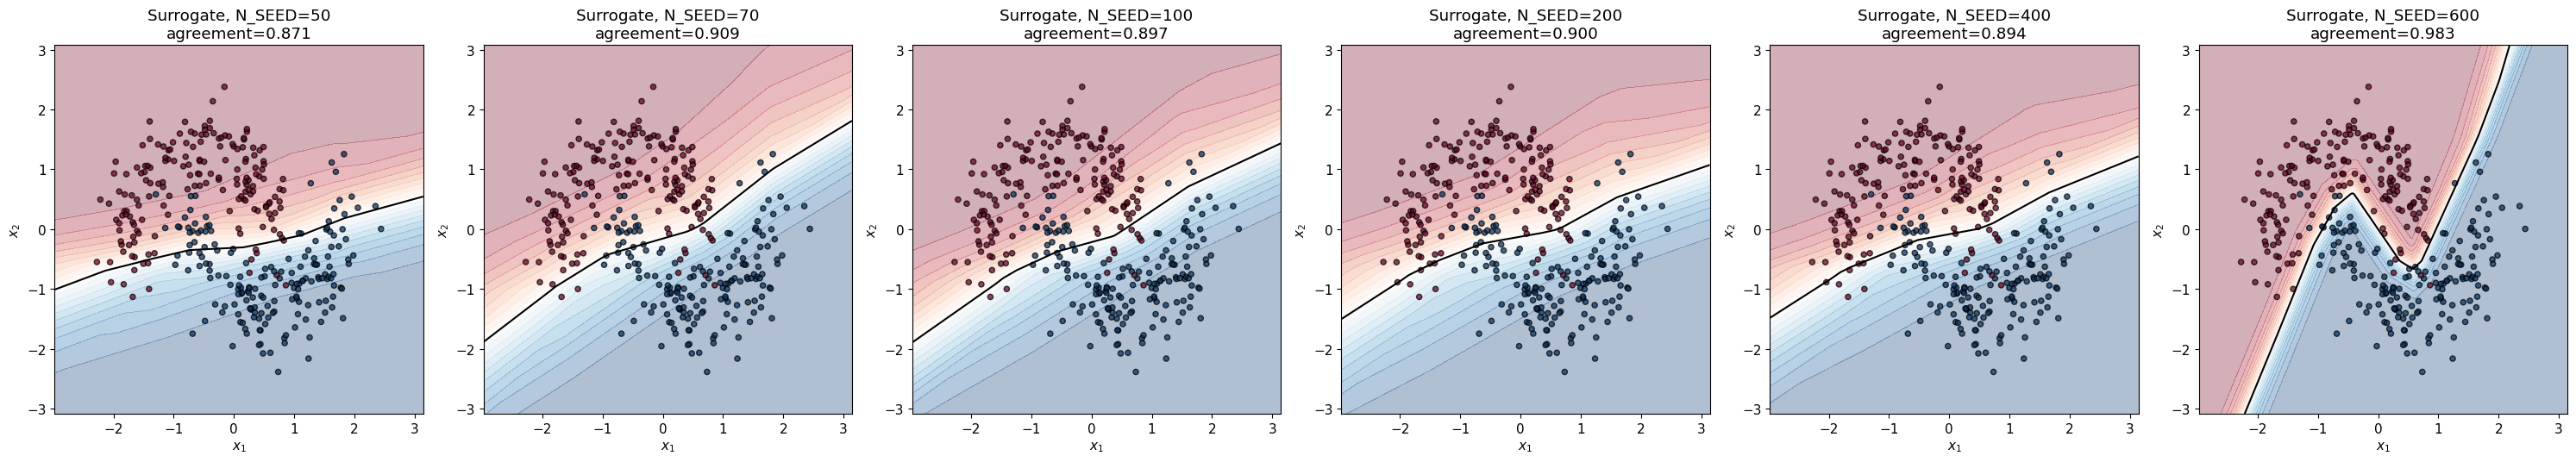

  N_SEED    queries    agreement
      50         50        0.871
      70         70        0.909
     100        100        0.897
     200        200        0.900
     400        400        0.894
     600        600        0.983


In [56]:
# N_SEED — сколько точек просим у label-only оракула.
# Используем 5 значений, в том числе более крупные, чтобы увидеть тренд.
seed_values = [50, 70, 100, 200, 400, 600]   

c1_results = []
surrogates_by_seed = {}

# Создаём 5 подграфиков в ряд (1 строка, 5 столбцов)
fig, axes = plt.subplots(1, len(seed_values), figsize=(5 * len(seed_values), 5.5))

for ax, n_seed in zip(axes, seed_values):
    # Случайно выбираем n_seed точек из train-выборки
    indices = rng.choice(len(X_train), size=n_seed, replace=False)
    X_seed = X_train[indices]

    # Сбрасываем счётчик и просим у label-only оракула метки
    label_oracle.queries = 0
    y_seed = label_oracle(X_seed)
    queries = label_oracle.queries

    # Обучаем surrogate (архитектура отличается от target)
    surrogate_model = MLPClassifier(
        hidden_layer_sizes=(12,),
        activation='relu',
        alpha=8e-4,
        max_iter=1500,
        random_state=SEED + 1
    ).fit(X_seed, y_seed)

    # Agreement — доля совпадающих предсказаний target и surrogate на тесте
    agreement = accuracy_score(target.predict(X_test), surrogate_model.predict(X_test))

    c1_results.append((n_seed, queries, agreement))
    surrogates_by_seed[n_seed] = surrogate_model

    # Рисуем границу surrogate
    plot_boundary(surrogate_model, X_test, y_test,
                  f'Surrogate, N_SEED={n_seed}\nagreement={agreement:.3f}', ax=ax)

plt.tight_layout()
plt.show()

# Печатаем таблицу C1
print(f"{'N_SEED':>8} {'queries':>10} {'agreement':>12}")
for n_seed, queries, agreement in c1_results:
    print(f"{n_seed:>8} {queries:>10} {agreement:>12.3f}")


surrogate = surrogates_by_seed[600]


**Таблица C1 для отчёта:**

| N_SEED | Запросов к оракулу | Agreement target/surrogate | Наблюдение о границах |
|---:|---:|---:|---|
| 50 | 50 | 0.871 | пойдет |
| 70 | 70 |  0.909 | пойдет |
| 100 | 100 | 0.897 | пойдет |
| 200| 200 | 0.900 | пойдет |
| 400 | 400 | 0.894 | пойдет |
| 600 | 600 | 0.983 | круто! |

## C2. Построение и проверка переноса возмущения

**Задание C2.** Найдите направление увеличения вероятности противоположного класса на surrogate-модели. Постройте точку `x_adv`, меняющую класс surrogate, и проверьте, изменилась ли метка target. Повторите эксперимент минимум для пяти исходных тестовых точек.

> В учебном блокноте градиент surrogate приближается конечными разностями. Это допустимо, поскольку surrogate — локальная модель. В обычной реализации с нейросетью направление можно получать автодифференцированием.

  №   idx  y0  surr  target  success       L2
  1     0   1     0       0     True    0.654
  2     1   1     0       0     True    0.688
  3     2   0     1       1     True    0.956
  4     3   0     1       0    False    0.336
  5     4   1     0       1    False    0.923

Успешных переносов: 3 из 5


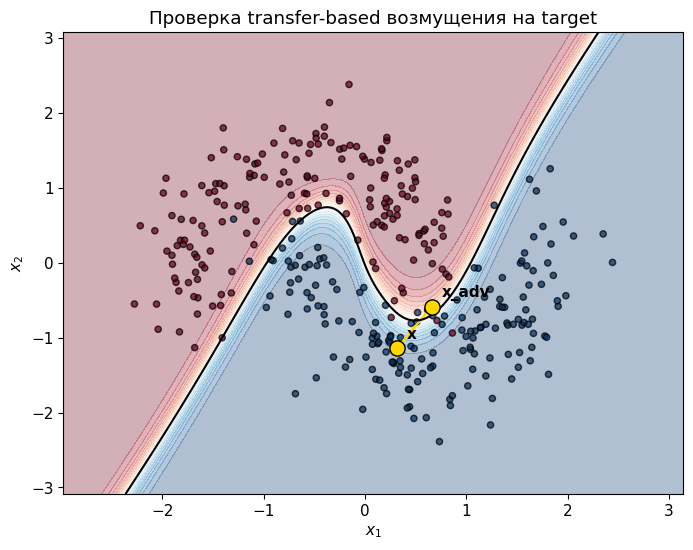

In [ ]:
# probability — вероятность заданного класса в точке (нужна для численного градиента).
def probability(model, x, class_index):
    return model.predict_proba(np.atleast_2d(x))[0, class_index]


# local_gradient — центральная конечная разность по каждой координате.
# На 2D-точку это 2·2=4 вызова predict_proba.
def local_gradient(model, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            probability(model, x + e, class_index) - probability(model, x - e, class_index)
        ) / (2 * h)
    return gradient


# first_boundary_crossing — идём вдоль direction, пока не сменится метка.
#мы ищем первую точку вдоль направления, где surrogate меняет решение. 
def first_boundary_crossing(model, x, source_label, direction, max_step=2.5, n_steps=150):
    for step in np.linspace(0, max_step, n_steps):
        candidate = x + step * direction
        if model.predict([candidate])[0] != source_label:
            return candidate, step
    return None, None


# Выбираем 5 тестовых точек, на которых target и surrogate согласны.
matching_ids = np.where(target.predict(X_test) == surrogate.predict(X_test))[0]
used_ids = matching_ids[:5]

# Прогоняем перенос для всех 5 точек и накапливаем результаты.
transfer_results = []

for pid in used_ids:
    xp = X_test[pid].copy()
    yp = int(target.predict([xp])[0])
    other = 1 - yp

    # Направление ухода от истинного класса — градиент surrogate по другому классу.
    g = local_gradient(surrogate, xp, other)
    d = g / (np.linalg.norm(g) + 1e-12)
    xa, st = first_boundary_crossing(surrogate, xp, yp, d)

    if xa is None:
        transfer_results.append((pid, yp, None, None, False, None))
        continue

    # Смотрим, что скажет surrogate и что скажет target на той же точке.
    surr_lab = int(surrogate.predict([xa])[0])
    targ_lab = int(target.predict([xa])[0])
    success = targ_lab != yp
    l2 = float(np.linalg.norm(xa - xp))
    transfer_results.append((pid, yp, surr_lab, targ_lab, success, l2))

# Печатаем таблицу C2.
print(f"{'№':>3} {'idx':>5} {'y0':>3} {'surr':>5} {'target':>7} {'success':>8} {'L2':>8}")
for i, (pid, yp, sl, tl, s, l2) in enumerate(transfer_results, 1):
    l2_str = '—' if l2 is None else f'{l2:.3f}'
    print(f"{i:>3} {pid:>5} {yp:>3} {str(sl):>5} {str(tl):>7} {str(s):>8} {l2_str:>8}")

n_success = sum(1 for r in transfer_results if r[4])
print(f"\nУспешных переносов: {n_success} из {len(transfer_results)}")

# Рисуем одну из успешных атак, чтобы было видно траекторию.
# Берём первую успешную; если успешных нет — первую с найденной точкой.
example = next((r for r in transfer_results if r[4]), transfer_results[0])
pid, yp, _, _, _, _ = example
xp = X_test[pid].copy()
other = 1 - yp
g = local_gradient(surrogate, xp, other)
d = g / (np.linalg.norm(g) + 1e-12)
xa, _ = first_boundary_crossing(surrogate, xp, yp, d)

fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Проверка transfer-based возмущения на target',
              ax=ax, points=[xp, xa], labels=['x', 'x_adv'])
ax.arrow(xp[0], xp[1], xa[0] - xp[0], xa[1] - xp[1],
         width=0.01, color='gold', length_includes_head=True)
plt.show()

**Таблица C2 для отчёта:**

| № опыта | Индекс исходной точки | Исходная метка | Метка surrogate для x_adv | Метка target для x_adv | Transfer success | L2-норма |
|---:|---:|---:|---:|---:|---|---:|
| 1 | 0 | 1 | 0 | 0 | True | 0.654 |
| 2 | 1 | 1 | 0 | 0 | True | 0.688 |
| 3 | 2 | 0 | 1 | 1 | True | 0.956 |
| 4 | 3 | 0 | 1 | 0 | False | 0.336 |
| 5 | 4 | 1 | 0 | 1 | False | 0.923 |

**Успешных переносов: 3 из 5.**


**Вывод по части C:**

Из 5 протестированных точек перенос с surrogate на target сработал в 3 случаях (success rate = 0.6). Успешные переносы (опыты 1–3) показывают, что adversarial-пример, построенный по градиенту surrogate, действительно пересекает решающую границу target. Неуспешные переносы (опыты 4–5) объясняются расхождением границ surrogate и target: в опыте 4 точка была близко к границе surrogate, но далеко от границы target, а в опыте 5 — наоборот, далеко от границы surrogate, и target не отреагировала. Это подтверждает ключевую идею transfer-based атак: успех переноса напрямую зависит от agreement между surrogate и target. Чем выше agreement (в C1 он был около 0.9), тем чаще перенос срабатывает. Однако даже при высоком agreement возможны неудачи, потому что вблизи границы решения surrogate и target могут расходиться.

# Часть D. Score-based сценарий: ZOO и NES

## D1. Реализация оценок направления

ZOO оценивает направление покоординатно конечными разностями. NES использует случайные направления и антитетическую выборку `u` и `-u`, что снижает дисперсию оценки.

**Задание D1.** Выполните ячейку, зафиксируйте количество запросов для ZOO и NES. Сравните косинусную близость оценённых направлений.


**Косинусная близость двух векторов:**

$$
\cos(\theta) = \frac{g_{zoo} \cdot g_{nes}}{\|g_{zoo}\| \cdot \|g_{nes}\|}
$$

- **1.0** — направления совпадают.
- **0.0** — направления перпендикулярны.
- **-1.0** — направления противоположны.

**Смысл:** насколько NES-оценка градиента похожа на ZOO-оценку. Если они указывают в одну сторону, значит NES хорошо оценивает направление, но использует больше запросов.

ZOO gradient: [0.208  0.3651]  запросов: 4
NES gradient: [0.1384 0.2105]  запросов: 80
Косинусная близость: 0.9980


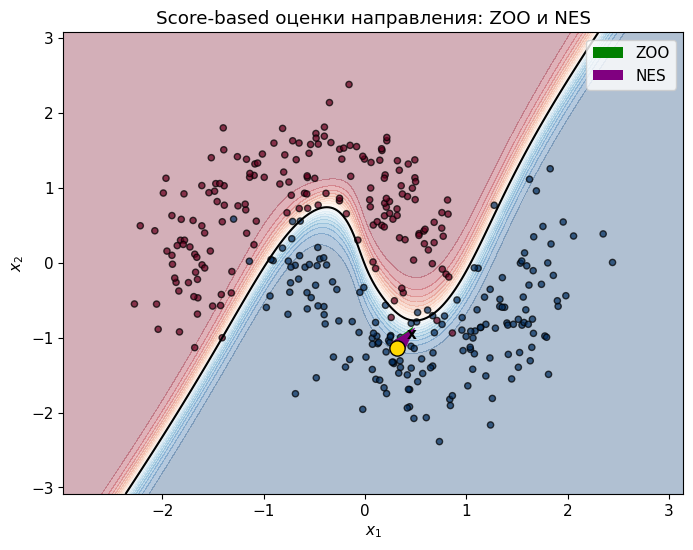

In [41]:
# score_loss — вероятность заданного класса, то что максимизируем.
def score_loss(oracle, x, class_index):
    return oracle(x)[0, class_index]


# zoo_gradient — покоординатная центральная разность. 2d запросов.
def zoo_gradient(oracle, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            score_loss(oracle, x + e, class_index) - score_loss(oracle, x - e, class_index)
        ) / (2 * h)
    return gradient


# nes_gradient — случайные направления с антитетической выборкой. 2·n_samples запросов.
def nes_gradient(oracle, x, class_index, sigma=0.08, n_samples=40, seed=SEED):
    local_rng = np.random.default_rng(seed)
    directions = local_rng.normal(size=(n_samples, len(x)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    estimate = np.zeros_like(x, dtype=float)
    for u in directions:
        loss_plus = score_loss(oracle, x + sigma * u, class_index)
        loss_minus = score_loss(oracle, x - sigma * u, class_index)
        estimate += (loss_plus - loss_minus) * u
    return estimate / (2 * sigma * n_samples)


# Берём точку из C2, которую уже определили.
x0 = X_test[int(matching_ids[0])].copy()
y0 = int(target.predict([x0])[0])
other_class = 1 - y0

# ZOO: 4 запроса в 2D.
score_oracle.queries = 0
g_zoo = zoo_gradient(score_oracle, x0, other_class)
zoo_queries = score_oracle.queries

# NES с 40 направлениями: 80 запросов.
NES_SAMPLES = 40
score_oracle.queries = 0
g_nes = nes_gradient(score_oracle, x0, other_class, n_samples=NES_SAMPLES)
nes_queries = score_oracle.queries

# Сравниваем направления через косинус.
cosine_similarity = np.dot(g_zoo, g_nes) / (np.linalg.norm(g_zoo) * np.linalg.norm(g_nes) + 1e-12)

print(f'ZOO gradient: {np.round(g_zoo, 4)}  запросов: {zoo_queries}')
print(f'NES gradient: {np.round(g_nes, 4)}  запросов: {nes_queries}')
print(f'Косинусная близость: {cosine_similarity:.4f}')

# Визуализируем оба направления на плоскости.
fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Score-based оценки направления: ZOO и NES',
              ax=ax, points=[x0], labels=['x'])
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)
ax.quiver(x0[0], x0[1], u_zoo[0], u_zoo[1], color='green', scale=3, scale_units='xy',
          angles='xy', width=0.009, label='ZOO')
ax.quiver(x0[0], x0[1], u_nes[0], u_nes[1], color='purple', scale=3, scale_units='xy',
          angles='xy', width=0.009, label='NES')
ax.legend()
plt.show()

## D2. Стоимость ZOO в пространствах разной размерности

**Задание D2.** Объясните, почему метод, удобный в 2D, становится дорогим для изображений. Сравните одностороннюю и центральную схемы конечных разностей.

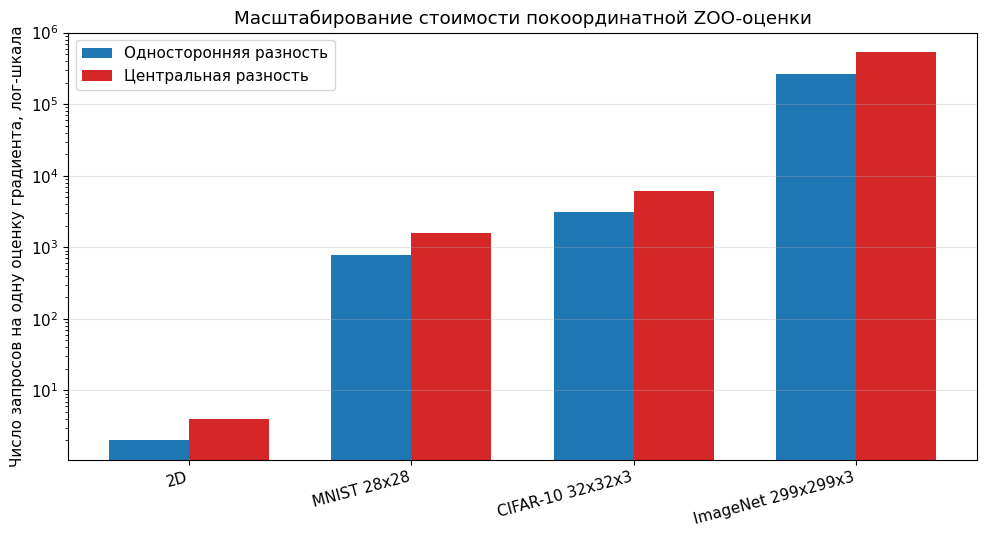

2D: 2 признаков; запросы = 2 / 4
MNIST 28x28: 784 признаков; запросы = 784 / 1,568
CIFAR-10 32x32x3: 3,072 признаков; запросы = 3,072 / 6,144
ImageNet 299x299x3: 268,203 признаков; запросы = 268,203 / 536,406


In [43]:
# Сравнение стоимости покоординатной оценки в разных размерностях.
dimensions = {
    '2D': 2,
    'MNIST 28x28': 28 * 28,
    'CIFAR-10 32x32x3': 32 * 32 * 3,
    'ImageNet 299x299x3': 299 * 299 * 3
}

names = list(dimensions.keys())
d = np.array(list(dimensions.values()))
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(positions - 0.18, d, width=0.36, label='Односторонняя разность', color='tab:blue')
ax.bar(positions + 0.18, 2 * d, width=0.36, label='Центральная разность', color='tab:red')
ax.set_yscale('log')
ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Число запросов на одну оценку градиента, лог-шкала')
ax.set_title('Масштабирование стоимости покоординатной ZOO-оценки')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, dimension in dimensions.items():
    print(f'{name}: {dimension:,} признаков; запросы = {dimension:,} / {2 * dimension:,}')

## D3. Исследование бюджета NES

**Задание D3.** Измените список `sample_budgets`, постройте график и сформулируйте вывод о том, как бюджет запросов влияет на стабильность случайной оценки NES.

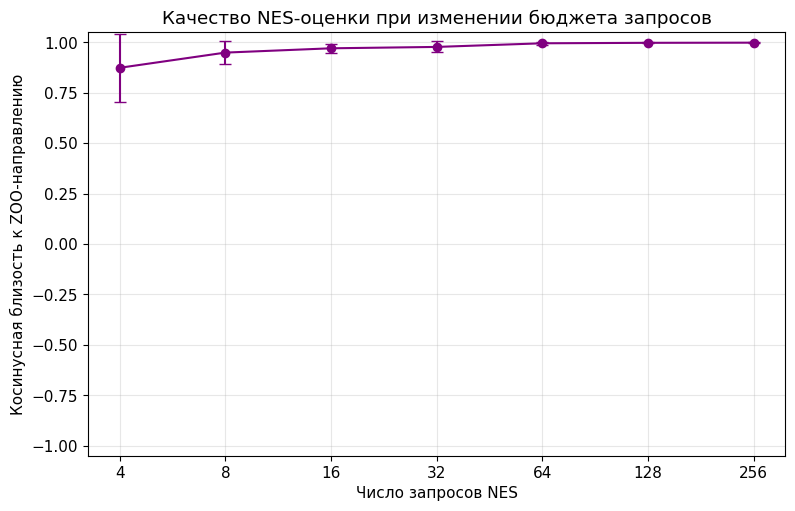

 n_samples    queries   mean_cos    std_cos
         2          4      0.874      0.170
         4          8      0.949      0.059
         8         16      0.970      0.024
        16         32      0.977      0.027
        32         64      0.995      0.008
        64        128      0.997      0.003
       128        256      0.998      0.002


In [44]:
# Прогоняем NES с разным числом направлений, сравнивая с ZOO-эталоном.
sample_budgets = [2, 4, 8, 16, 32, 64, 128]
repetitions = 10
reference = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
mean_cosines, std_cosines, query_budgets = [], [], []

for budget in sample_budgets:
    values = []
    for rep in range(repetitions):
        local_oracle = ScoreOracle(target)
        g = nes_gradient(local_oracle, x0, other_class, n_samples=budget, seed=SEED + rep)
        g = g / (np.linalg.norm(g) + 1e-12)
        values.append(float(np.dot(reference, g)))
    mean_cosines.append(np.mean(values))
    std_cosines.append(np.std(values))
    query_budgets.append(2 * budget)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(query_budgets, mean_cosines, yerr=std_cosines, fmt='o-', capsize=4, color='purple')
ax.set_xscale('log', base=2)
ax.set_xticks(query_budgets)
ax.set_xticklabels(query_budgets)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Число запросов NES')
ax.set_ylabel('Косинусная близость к ZOO-направлению')
ax.set_title('Качество NES-оценки при изменении бюджета запросов')
ax.grid(alpha=0.3)
plt.show()

print(f"{'n_samples':>10} {'queries':>10} {'mean_cos':>10} {'std_cos':>10}")
for budget, q, m, s in zip(sample_budgets, query_budgets, mean_cosines, std_cosines):
    print(f"{budget:>10} {q:>10} {m:>10.3f} {s:>10.3f}")

**Таблица D для отчёта:**

| Метод / настройка | Число запросов | Косинусная близость / наблюдение | Вывод |
|---|---:|---|---|
| ZOO | 4 | — (эталон, cos = 1.0) | Базовая оценка градиента; служит эталоном для сравнения |
| NES, n_samples = 2 | 4 | mean_cos = 0.874, std_cos = 0.170 | При равном числе запросов NES заметно уступает ZOO и даёт высокий разброс |
| NES, n_samples = 4 | 8 | mean_cos = 0.949, std_cos = 0.059 | Уже лучше, но всё ещё хуже ZOO при том же бюджете (4 запроса у ZOO против 8 у NES) |
| NES, n_samples = 8 | 16 | mean_cos = 0.970, std_cos = 0.024 | Близость высокая, разброс падает; но запросов в 4 раза больше, чем у ZOO |
| NES, n_samples = 16 | 32 | mean_cos = 0.977, std_cos = 0.027 | Качество стабилизируется, но цена — 32 запроса против 4 у ZOO |
| NES, n_samples = 32 | 64 | mean_cos = 0.995, std_cos = 0.008 | Почти совпадает с ZOO, однако требует в 16 раз больше запросов |
| NES, n_samples = 64 | 128 | mean_cos = 0.997, std_cos = 0.003 | Практически идентично ZOO, но 128 запросов — очень дорого |
| NES, n_samples = 128 | 256 | mean_cos = 0.998, std_cos = 0.002 | Максимальная близость; накладные расходы enormous (256 запросов) |

**Общий вывод:**  
- ZOO даёт эталонное направление градиента всего за **4 запроса**.  
- NES приближается к ZOO по косинусной близости только при значительном увеличении числа запросов:  
  - при 4 запросах (n_samples=2) cos ≈ 0.874 — ещё далеко;  
  - при 64 запросах (n_samples=32) cos ≈ 0.995 — уже близко;  
  - при 256 запросах (n_samples=128) cos ≈ 0.998 — практически совпадает.  
- **Цена:** чтобы догнать ZOO по точности направления, NES тратит в **16–64 раза больше запросов**.

ZOO считает градиент по каждой координате отдельно. В нашей двумерной задаче ему нужно 2 * 2 = 4 запроса. NES идёт по случайным направлениям. При n_samples = 40 ему нужно 2 * 40 = 80 запросов.

Несмотря на разное число запросов, направления градиента у ZOO и NES почти совпали: косинусная близость 0.9980. Это значит, что NES правильно угадывает направление, куда нужно двигаться.

Отдельно проверили, как качество NES зависит от числа случайных направлений. При n_samples = 2 средняя близость 0.874, а разброс большой (0.170). То есть при малом числе направлений NES шумит: каждый запуск даёт разный результат. При n_samples = 8 средняя близость уже 0.970, а разброс падает до 0.024. При n_samples = 128 близость 0.998, разброс всего 0.002 — практически как ZOO.

Вывод: NES становится точнее при увеличении числа направлений, но за это платит ростом числа запросов. В двумерной задаче ZOO выгоднее: 4 запроса против 80. Зато в многомерных задачах, например для изображений, ZOO требует слишком много запросов, а NES — нет. Поэтому выбор метода зависит от задачи: в малой размерности лучше ZOO, в большой — NES.

# Часть E. Decision-based сценарий

## E1. Бинарный поиск решающей границы

Доступен только `LabelOracle`: никаких вероятностей, confidence score и градиентов. Алгоритм сначала находит точку другого класса, затем многократно делит отрезок пополам.

**Задание E1.** Выполните ячейку. Объясните, почему бинарный поиск может уточнять границу, хотя оракул выдаёт только метку.

Метка x0: 1
Метка точки другой области: 0
Расстояние ||x_outside - x0||_2: 0.44685
Запросов на поиск границы: 35


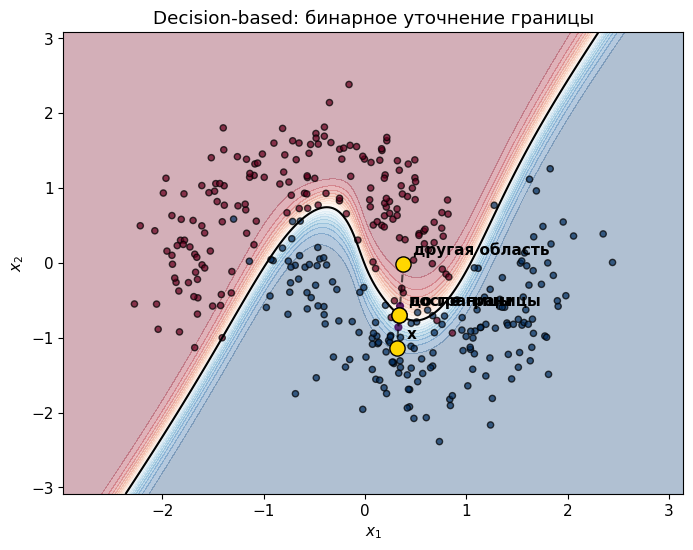

In [62]:
# find_opposite_point — ищем точку другого класса случайными пробами.
def find_opposite_point(oracle, x, source_label, radius=1.0, trials=3000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    low = X_train.min(axis=0) - 0.5
    high = X_train.max(axis=0) + 0.5
    for _ in range(trials):
        candidate = x + radius * local_rng.normal(size=len(x))
        if np.any(candidate < low) or np.any(candidate > high):
            continue
        if oracle(candidate)[0] != source_label:
            return candidate
    raise RuntimeError('Точка другого класса не найдена.')

# binary_boundary_search — делим отрезок вдвое на каждой итерации.
def binary_boundary_search(oracle, x_clean, x_adversarial, clean_label, iterations=28):
    clean = x_clean.copy()
    adversarial = x_adversarial.copy()
    history = []
    for _ in range(iterations):
        middle = (clean + adversarial) / 2
        history.append(middle.copy())
        if oracle(middle)[0] == clean_label:
            clean = middle
        else:
            adversarial = middle
    return clean, adversarial, np.asarray(history)


label_oracle.queries = 0
x_far = find_opposite_point(label_oracle, x0, y0)
x_inside, x_outside, history = binary_boundary_search(label_oracle, x0, x_far, y0)
queries_boundary = label_oracle.queries

print('Метка x0:', label_oracle(x0)[0])
print('Метка точки другой области:', label_oracle(x_far)[0])
print(f'Расстояние ||x_outside - x0||_2: {np.linalg.norm(x_outside - x0):.5f}')
print('Запросов на поиск границы:', queries_boundary)

fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Decision-based: бинарное уточнение границы',
              ax=ax, points=[x0, x_far, x_inside, x_outside],
              labels=['x', 'другая область', 'до границы', 'после границы'])
ax.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)
ax.scatter(history[:, 0], history[:, 1], c=np.arange(len(history)), cmap='viridis',
           s=24, alpha=0.85)
plt.show()

## E2. Анализ сходимости бинарного поиска

**Задание E2.** Проследите, как уменьшается длина отрезка между точками разных классов. Сравните результаты для 5, 10, 20 и 28 итераций.

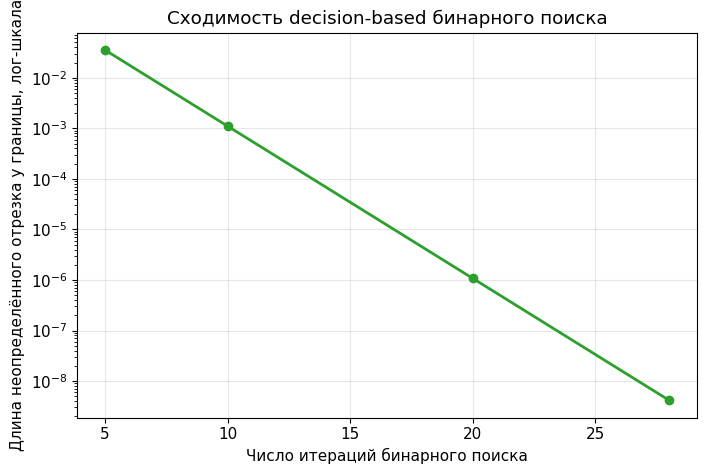

Итераций:  5; длина отрезка: 0.03528667; запросов: 5
Итераций: 10; длина отрезка: 0.00110271; запросов: 10
Итераций: 20; длина отрезка: 0.00000108; запросов: 20
Итераций: 28; длина отрезка: 0.00000000; запросов: 28


In [ ]:
# Прогоняем бинарный поиск с разным числом итераций и смотрим, как сжимается отрезок.
iteration_values = [5, 10, 20, 28]
distances, used_queries = [], []

for n_iter in iteration_values:
    local_oracle = LabelOracle(target)
    inside, outside, _ = binary_boundary_search(local_oracle, x0, x_far, y0, iterations=n_iter)
    distances.append(np.linalg.norm(outside - inside))
    used_queries.append(local_oracle.queries)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iteration_values, distances, marker='o', linewidth=2, color='tab:green')
ax.set_yscale('log')
ax.set_xlabel('Число итераций бинарного поиска')
ax.set_ylabel('Длина неопределённого отрезка у границы, лог-шкала')
ax.set_title('Сходимость decision-based бинарного поиска')
ax.grid(alpha=0.3)
plt.show()

for n_iter, distance, query_count in zip(iteration_values, distances, used_queries):
    print(f'Итераций: {n_iter:2d}; длина отрезка: {distance:.8f}; запросов: {query_count}')

**Вывод по части E:**

При доступе только к итоговой метке можно найти точку на решающей границе, используя геометрический поиск. Сначала случайными пробами находится точка другого класса, затем между исходной точкой и этой точкой выполняется бинарный поиск: на каждой итерации отрезок делится пополам, и по метке середины определяется, в какой половине лежит граница. С увеличением числа итераций длина отрезка быстро уменьшается: после 5 итераций она равна 0.0353, после 10 — 0.0011, после 20 — 0.00000108, а после 28 — практически нулю. Это означает, что бинарный поиск сходится экспоненциально: каждая итерация уменьшает длину отрезка примерно вдвое. При этом число запросов растёт линейно — ровно 1 запрос на итерацию, то есть 28 запросов за 28 итераций.

Ограничение подхода состоит в том, что для запуска бинарного поиска нужно сначала найти точку другого класса, а это делается случайными пробами и может потребовать сотни или тысячи запросов. Кроме того, поиск ограничен отрезком между двумя точками, поэтому он находит только одну точку границы, а не всю её форму. В сравнении с score-based сценарием отсутствует информация о вероятностях классов: нет ни уверенности модели, ни градиента, поэтому нельзя построить направление атаки напрямую. Приходится работать только с метками 0/1, что делает decision-based метод значительно дороже по числу запросов, чем ZOO или NES. Однако у него есть важное преимущество: он работает в самом строгом сценарии, когда атакующий не видит ничего, кроме итогового ответа модели.

# Часть F. Итоговый анализ

## F1. Сравнительная таблица

Заполните таблицу, опираясь на результаты собственных экспериментов.

# Итоговая таблица

| Критерий | Transfer-based | Score-based | Decision-based |
|---|---|---|---|
| Доступная информация | Метки target для обучения surrogate | Вероятности / логиты | Только метка класса |
| Метод в работе | Surrogate + локальное возмущение + перенос на target | ZOO (центральная разность) и NES (случайные направления) | Случайный поиск другой точки + бинарный поиск границы |
| Запросы к цели | Разметка обучающего набора: `N_SEED` | ZOO: `2d`; NES: `2n` | Поиск `x_far` + 1 запрос на итерацию бинарного поиска |
| Стоимость запросов | Зависит от размера обучающего набора | ZOO — линейно от размерности; NES — линейно от числа направлений | Значительно больше; растёт с числом итераций |
| Преимущество | Запросы к target не нужны на этапе оптимизации возмущения | Непрерывный сигнал для точной оценки градиента | Работает при минимальном уровне доступа |
| Ограничение | Зависимость от agreement surrogate и target; качество переноса нестабильно | `2d` запросов дороги в высокой размерности; NES шумит при малом бюджете | Большое число запросов; находится лишь одна точка границы |
| Защита | Ограничение числа запросов на разметку; ансамбли моделей; усложнение переноса | Скрывать вероятности; добавлять шум в score; квоты запросов | Квоты и задержки запросов; рандомизация ответов; ансамбли |

## F2. Контрольные вопросы

1. Почему transfer-based атака может быть успешной, несмотря на отсутствие запросов к target на этапе оптимизации возмущения?
Разные модели часто учатся на похожих данных и имеют схожие границы решений, поэтому возмущение, ломающее surrogate, часто   ломает и target.

2. Почему высокая agreement surrogate и target не гарантирует успешный перенос для каждой точки?  
Agreement — усреднённая метрика; в отдельных точках границы решений могут расходиться, особенно вблизи границы.  

3. Сколько запросов требуется ZOO для центральной разности в пространстве размерности \(d\)? Почему это проблематично для изображений?  
2d запросов на одну оценку градиента. Для изображений d огромно, поэтому это крайне дорого  

4. Как антитетическая выборка в NES влияет на дисперсию оценки?  
Использование пар +u -u снижает дисперсию оценки градиента.

5. Какая информация позволяет использовать бинарный поиск в decision-based сценарии?  
Только бинарный ответ модели: «правильно/неправильно». Этого достаточно, чтобы искать границу между исходным и состязательным примером.  

6. Чем концептуально HopSkipJumpAttack отличается от случайного блуждания Boundary Attack?  
Boundary Attack — случайное блуждание вдоль границы; HopSkipJump использует оценки градиента/направления и бинарный поиск, поэтому сходится быстрее и точнее.  

7. Какие меры защиты уменьшают риск чёрно-ящичных атак на ML-систему?  
Adversarial training, ансамбли, ограничение запросов, детекторы аномалий и т.д.